Criar um dataset com as 43 empresas cotadas em Bolsa

# Governação Corporativa na Bolsa Portuguesa
## Rede de Accionistas e Conselhos de Administração

---

## 1. Metodologia de Recolha de Dados

Os dados foram recolhidos através de dois processos independentes — um de *web scraping* para os accionistas e um *pipeline* de extracção documental com IA para os membros dos conselhos de administração — que convergem num grafo único de relações corporativas.

---

### Fluxograma Geral

```
┌─────────────────────────────────┐     ┌──────────────────────────────────────┐
│   FONTE A: Euronext Lisboa      │     │   FONTE B: CMVM / Site do Governo    │
│   (participações accionistas)   │     │   (relatórios de governo societário) │
└────────────────┬────────────────┘     └──────────────────┬───────────────────┘
                 │                                         │
                 ▼                                         ▼
      ┌──────────────────┐                    ┌────────────────────┐
      │   scrapper.py    │                    │  pass0 — Mapping   │
      │  Selenium + API  │                    │  PDF → empresa ID  │
      └────────┬─────────┘                    └─────────┬──────────┘
               │                                        │
               │                              ┌─────────▼──────────┐
               │                              │  pass1 — PDF→TXT   │
               │                              │    pdfplumber       │
               │                              └─────────┬──────────┘
               │                                        │
               │                              ┌─────────▼──────────┐
               │                              │  pass2 — TXT→JSON  │
               │                              │  Gemini 2.5 Pro    │
               │                              │  + validação nomes │
               │                              └─────────┬──────────┘
               │                                        │
               └──────────────┬─────────────────────────┘
                              │
                              ▼
                 ┌────────────────────────┐
                 │  pass3 — JSON → CSV    │
                 │  dataset.csv           │
                 │  edges.csv             │
                 └────────────┬───────────┘
                              │
                              ▼
                 ┌────────────────────────┐
                 │  pass4 — Validação     │
                 │  Relatório de qualidade│
                 └────────────────────────┘
```

---

### 1.1 Accionistas — Scraping da Euronext Lisboa (`scrapper.py`)

**Fonte:** [live.euronext.com](https://live.euronext.com) — página de cada empresa cotada  
**Input:** `Euronext_Equities_2026-04-07.csv` (lista de empresas activas com ISIN e ticker)  
**Output:** `dataset.csv` (nós) · `edges.csv` (participações em %)

**Processo:**
```
Euronext_Equities.csv
        │
        ▼
Filtrar empresas activas (Open Price ≠ "-")
        │
        ▼
Para cada empresa:
  ├─ Navegar para página da empresa (Selenium / headless Chrome)
  ├─ Estratégia 1: DOM parsing — detectar tabela com coluna de percentagens
  ├─ Estratégia 2 (fallback): chamada directa à API Euronext (/pd_es endpoint)
  └─ Extrair accionistas → criar nó "shareholder" + aresta com peso = % capital
        │
        ▼
Deduplicar nós e arestas → guardar dataset.csv + edges.csv
```

**Notas técnicas:**
- IDs dos nós normalizados por *slugify* (minúsculas, sem pontuação, espaços→`_`)
- Pausa de 1 segundo entre pedidos (*polite scraping*)
- Accionistas que são empresas cotadas ficam ligados como nó do tipo `company`; restantes como `shareholder`
- Peso da aresta = percentagem de capital detida

---

### 1.2 Conselhos de Administração — Pipeline de 4 Passos

Os relatórios de governo societário são de publicação obrigatória (Código de Valores Mobiliários) e disponibilizados anualmente pela CMVM.

#### Passo 0 — Mapeamento PDF → Empresa (`pass0_gerar_mapping.py`)

```
PDFs em E:\Sociedade_dados\       dataset.csv
            │                         │
            └────────────┬────────────┘
                         ▼
          Normalizar nomes (slugify + fuzzy match)
                         │
                         ▼
            pdf_company_mapping.csv
            (pdf_filename → company_id)
```

#### Passo 1 — PDF → TXT (`pass1_extrair_txt.py`)

```
*.pdf (relatório de governo societário)
        │
        ▼
  pdfplumber — extracção página a página
        ├─ Texto corrido
        └─ Tabelas (formato pipe-separated)
        │
        ▼
  *.txt com marcadores === PAGE N === e --- TABLE N.M ---
  (preserva estrutura para facilitar extracção pela IA)
```

#### Passo 2 — TXT → JSON com IA (`pass2_gemini_extrair_nomes.py`)

```
*.txt
  │
  ▼
Extrair excerto relevante (até 20 000 chars)
  ├─ Prioridade: secções "composição do conselho", "membros executivos"
  └─ Fallback: secções "administração", "governo societário"
  │
  ▼
Prompt em português → Gemini 2.5 Pro (JSON mode estruturado)
  ├─ Instrução: extrair APENAS nomes de pessoas do Conselho de Administração
  ├─ Excluir: cargos, frases, empresas, outros órgãos, biografias
  └─ Schema forçado: { company, members: [string], notes }
  │
  ▼
Validação dos nomes (heurísticas portuguesas):
  ├─ Mínimo 2 palavras, máximo 10
  ├─ Rejeitar se começa por palavra-chave de frase ("cargo de", "data", ...)
  ├─ Rejeitar se contém marcador de empresa ("S.A.", "SGPS", "Banco", ...)
  └─ Todas as palavras de conteúdo começam por maiúscula
  │
  ▼
Gate de qualidade: > 10% entradas inválidas → reprocessar
  │
  ▼
*_members.json  { company, members[], notes, model_name, created_at }
```

#### Passo 3 — JSON → CSV (`pass3_atualizar_datasets.py`)

```
dataset.csv + edges.csv (existentes)
*_members.json (novos)
        │
        ▼
Remover arestas de conselho antigas (weight < 1.0)
Remover nós pessoa sem outras ligações
        │
        ▼
Para cada JSON aceite (gate de qualidade):
  ├─ Limpar nomes → criar nós tipo "person"
  ├─ Criar arestas person → company (weight ∈ [0.1, 0.5])
  └─ Deduplicar por (source, target)
        │
        ▼
dataset.csv actualizado · edges.csv actualizado · board_extraction_log.csv
```

#### Passo 4 — Validação (`pass4_validar_log.py`)

```
board_extraction_log.csv
        │
        ▼
Relatório: empresas processadas · skipped · sem membros · outliers
```

---

### 1.3 Estrutura dos Dados Finais

| Ficheiro | Conteúdo | Colunas |
|---|---|---|
| `dataset.csv` | Nós do grafo | `id`, `label`, `type` (company / person) |
| `edges.csv` | Arestas do grafo | `source`, `target`, `weight` |

**Convenção de pesos nas arestas:**

| Tipo de aresta | Weight | Interpretação |
|---|---|---|
| Accionista → Empresa | ≥ 1 | % de capital detido |
| Membro conselho → Empresa | 0.1 – 0.5 | Marcador de pertença (sem valor quantitativo) |

---

### 1.4 Limitações

- **Extracção incompleta:** o Gemini por vezes extrai apenas o Presidente quando a lista completa está em formato tabular complexo no PDF — 13 empresas têm menos de 4 membros extraídos e requerem revisão manual.
- **Accionistas genéricos:** `outros_accionistas`, `freefloat` e `autodetencao` são categorias contabilísticas presentes no scraping da Euronext, não entidades reais — criam ligações artificiais entre empresas e devem ser filtrados nas análises.
- **Empresas sem PDF:** 6 empresas (CUF, Fidelidade, Grupo José de Mello, Luz Saúde, entre outras) não tinham PDF disponível ou o PDF gerou extracção com qualidade insuficiente — os respectivos JSONs foram corrigidos manualmente.
- **Cobertura:** os dados referem-se aos relatórios do exercício de 2024, publicados em 2025.

In [1]:
import pandas as pd

empresas = pd.read_csv(
    "Euronext_Equities_2026-04-07.csv",
    sep=";",
    skiprows=[1, 2, 3]

)

empresas.head()

,Name,ISIN,Symbol,Market,Currency,Open Price,High Price,low Price,last Price,last Trade MIC Time,Time Zone,Volume,Turnover,Closing Price,Closing Price DateTime
0,ALTRI SGPS,PTALT0AE0002,ALTR,Euronext Lisbon,EUR,4.91,4.985,4.82,4.835,02/04/2026 21:35,BST,544062,2654995.26,4.835,02/04/2026
1,ARRABIDASHOPPING,PTCAP0AM0017,MLARR,Euronext Access Lisbon,EUR,-,-,-,-,-,BST,-,-,-,-
2,ATRIUM BIRE SIGI,PTTBI0AM0006,MLATR,Euronext Access Lisbon,EUR,2.98,2.98,2.98,2.98,05/08/2025 21:00,BST,16780,50004.40,2.98,02/04/2026
3,B.COM.PORTUGUES,PTBCP0AM0015,BCP,Euronext Lisbon,EUR,0.86,0.868,0.8488,0.8646,02/04/2026 21:35,BST,69179682,59416046.70,0.8646,02/04/2026
4,BENFICA,PTSLB0AM0010,SLBEN,Euronext Lisbon,EUR,6.36,6.62,6.34,6.34,02/04/2026 15:59,BST,273,1787.28,6.34,02/04/2026


In [3]:
empresas = empresas[empresas["Open Price"] != "-"]
empresas = empresas.iloc[:, [0]]
empresas.head(10)

,Name
0,ALTRI SGPS
2,ATRIUM BIRE SIGI
3,B.COM.PORTUGUES
4,BENFICA
5,CIAGEST - SIGI S.A
6,CONDURIL
7,CORTICEIRA AMORIM
8,CTT CORREIOS PORT
9,EDP
10,EDP RENOVAVEIS


In [4]:
empresas.to_csv("empresas.csv", index = False)

In [10]:
edges = pd.read_csv("edges.csv")
edges.head(10)

,source,target,weight
0,promendo_investimentos_sa,altri_sgps,17.54
1,caderno_azul_sa,altri_sgps,16.67
2,actium_capital_sa,altri_sgps,14.17
3,vieira_de_matos_vdm_capital_sa,altri_sgps,12.35
4,1_thing_investments_sa,altri_sgps,10.01
5,bankinter_private_clients,atrium_bire_sigi,66.25
6,kostas_holding_unipessoal_lda,atrium_bire_sigi,20.00
7,bankinter_investment_sa,atrium_bire_sigi,10.00
8,sierra_developments_holding_bv,atrium_bire_sigi,3.75
9,groupe_fosun,bcomportugues,20.03


In [11]:
edges.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   source  153 non-null    str    
 1   target  153 non-null    str    
 2   weight  153 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.7 KB


# O gráfico completo


In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

dataset = pd.read_csv("dataset.csv")
edges    = pd.read_csv("edges.csv")

board_edges       = edges[edges["weight"] < 1].copy()
shareholder_edges = edges[edges["weight"] >= 1].copy()

company_ids = set(dataset.loc[dataset["type"] == "company", "id"])
person_ids  = set(dataset.loc[dataset["type"] == "person",  "id"])

print(f"Empresas: {len(company_ids)} | Pessoas: {len(person_ids)}")
print(f"Arestas membros conselho: {len(board_edges)} | Arestas accionistas: {len(shareholder_edges)}")

Empresas: 51 | Pessoas: 366
Arestas membros conselho: 267 | Arestas accionistas: 148


### 1. Rede completa — empresas e membros do conselho

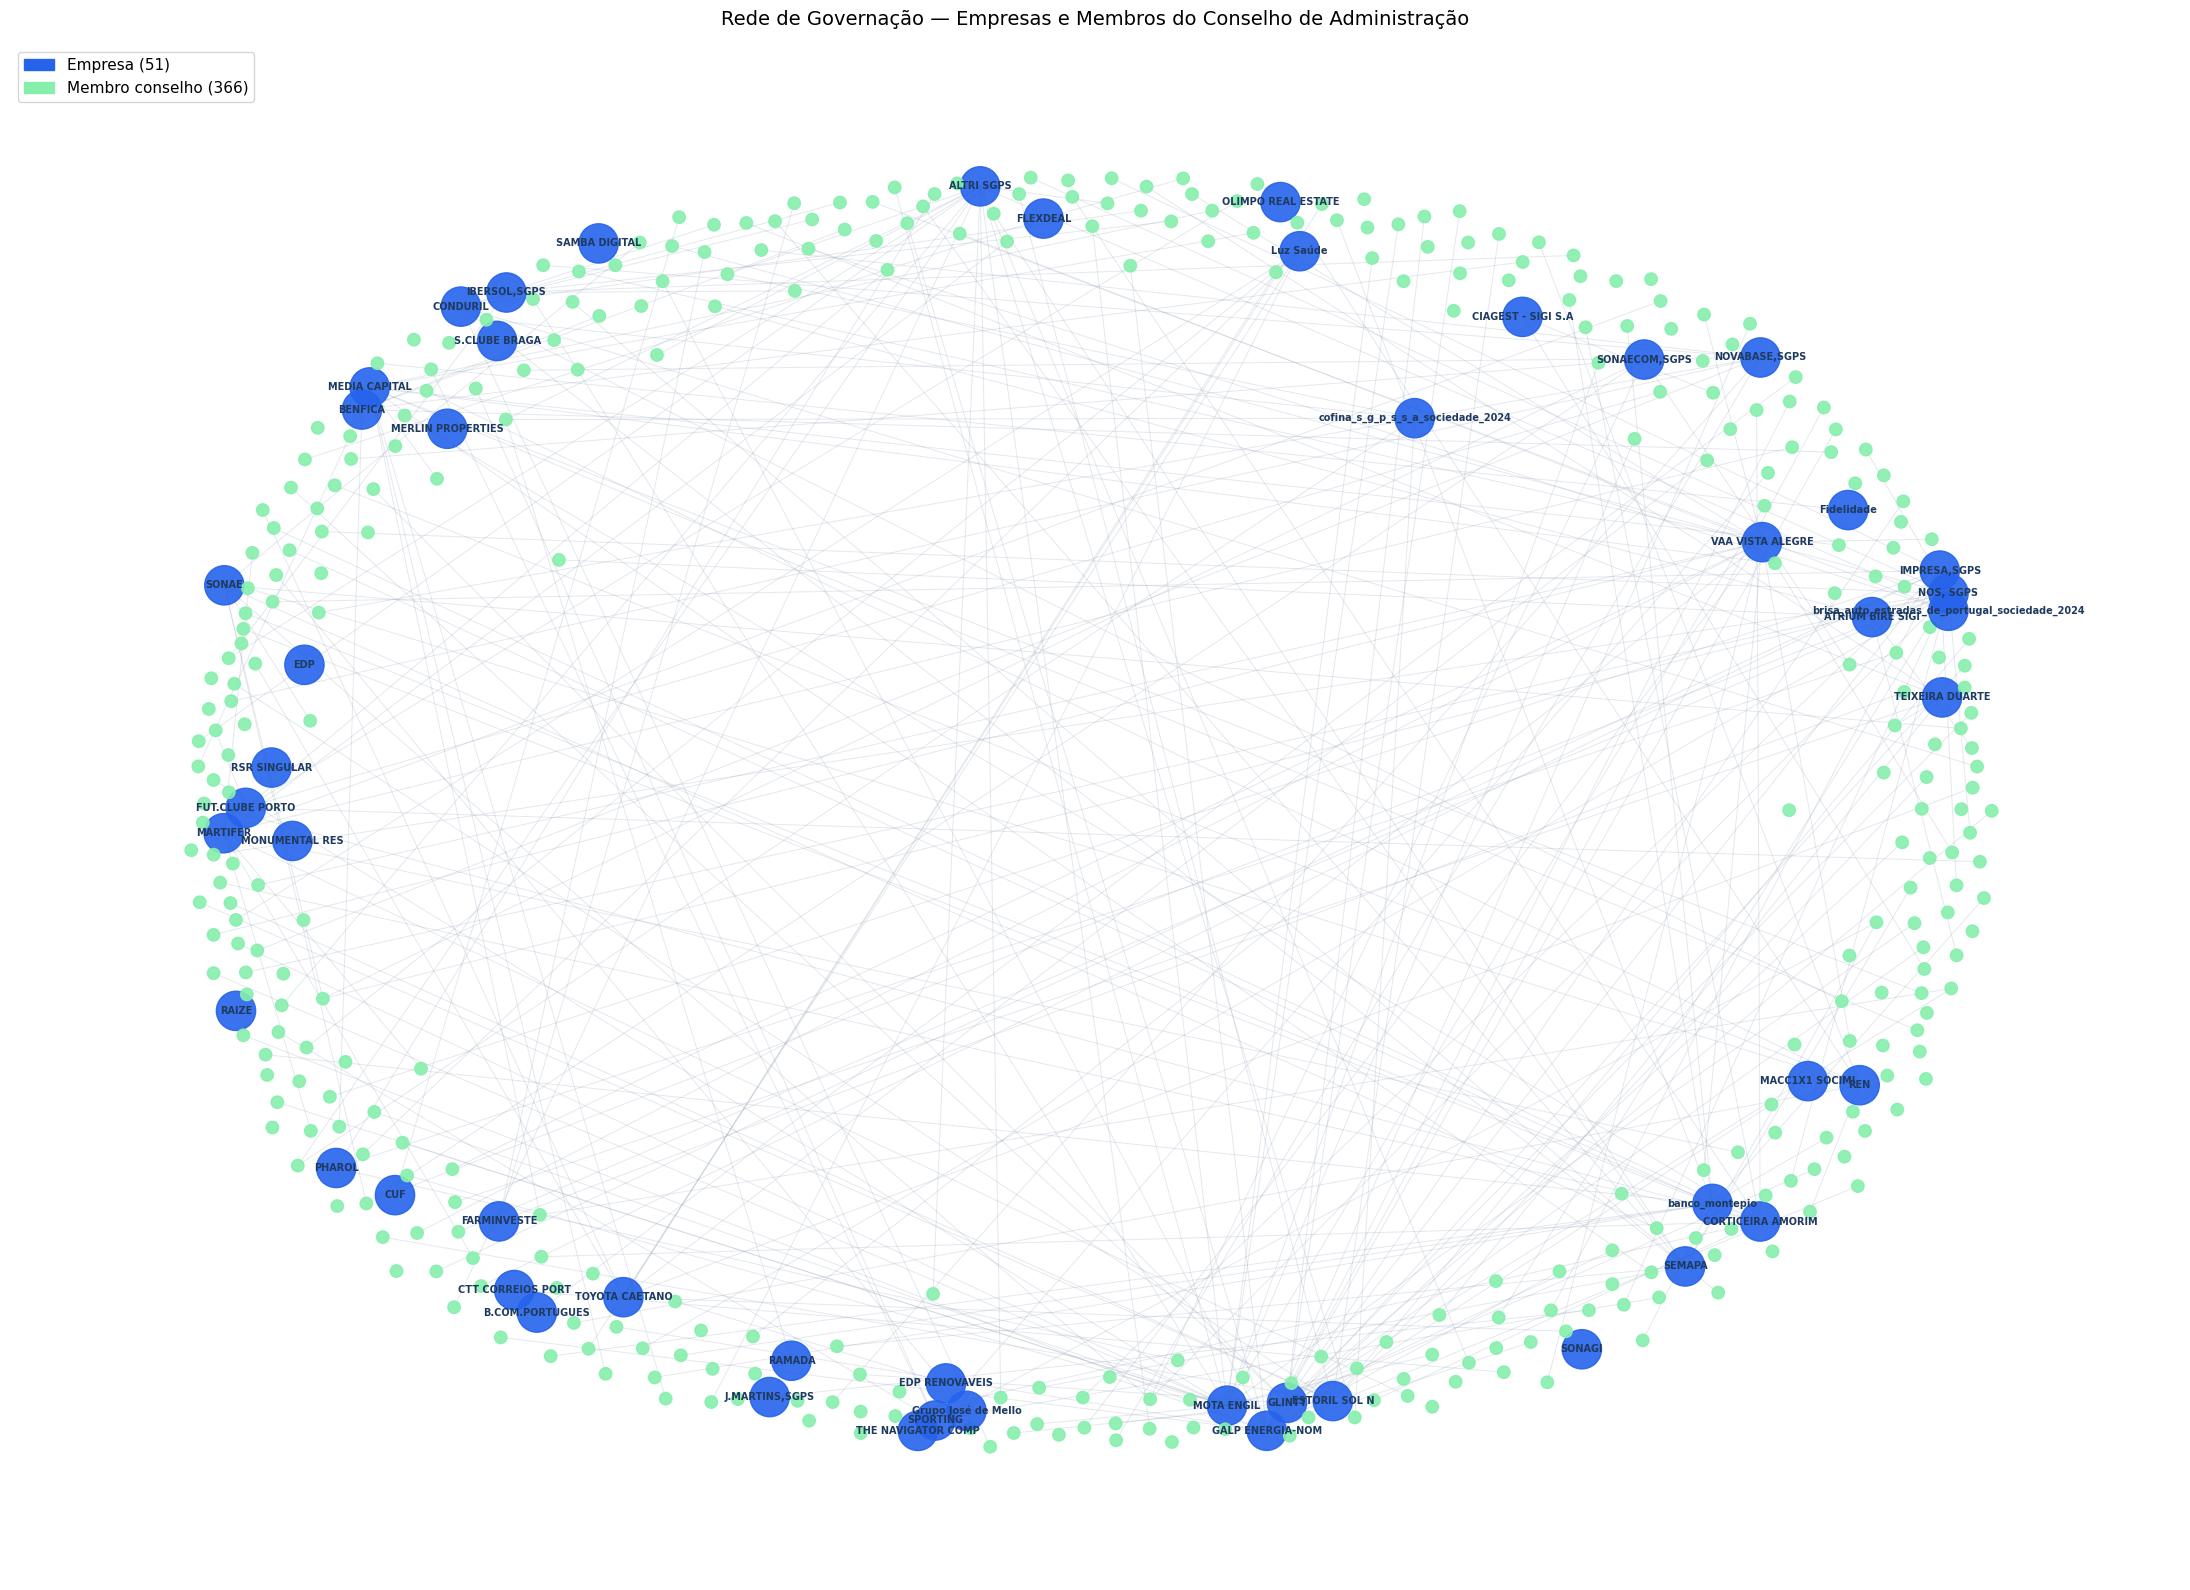

Imagem guardada: rede_conselho.png


In [7]:
G_board = nx.Graph()

for _, row in dataset.iterrows():
    G_board.add_node(row["id"], label=row["label"], node_type=row["type"])

for _, row in board_edges.iterrows():
    G_board.add_edge(row["source"], row["target"])

# Nodes visuals
node_colors = ["#2563EB" if G_board.nodes[n].get("node_type") == "company" else "#86EFAC"
               for n in G_board.nodes]
node_sizes  = [800 if G_board.nodes[n].get("node_type") == "company" else 80
               for n in G_board.nodes]

# Only label company nodes
labels = {n: G_board.nodes[n].get("label", n)
          for n in G_board.nodes
          if G_board.nodes[n].get("node_type") == "company"}

pos = nx.spring_layout(G_board, seed=42, k=1.8)

fig, ax = plt.subplots(figsize=(22, 16))
nx.draw_networkx_edges(G_board, pos, ax=ax, alpha=0.25, width=0.7, edge_color="#94A3B8")
nx.draw_networkx_nodes(G_board, pos, ax=ax,
                       node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G_board, pos, labels=labels, ax=ax,
                        font_size=7, font_weight="bold", font_color="#1E3A5F")

legend = [
    mpatches.Patch(color="#2563EB", label=f"Empresa ({len(company_ids)})"),
    mpatches.Patch(color="#86EFAC", label=f"Membro conselho ({len(person_ids)})"),
]
ax.legend(handles=legend, loc="upper left", fontsize=11)
ax.set_title("Rede de Governação — Empresas e Membros do Conselho de Administração", fontsize=14, pad=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("rede_conselho.png", dpi=150, bbox_inches="tight")
plt.show()
print("Imagem guardada: rede_conselho.png")

### 2. Conselhos interligados — empresas que partilham membros

Pares com mais membros partilhados:
  ALTRI SGPS  <->  cofina_s_g_p_s_s_a_sociedade_2024  : 4 membro(s) partilhado(s)
  NOS, SGPS  <->  SONAE  : 3 membro(s) partilhado(s)
  NOS, SGPS  <->  SONAECOM,SGPS  : 3 membro(s) partilhado(s)
  SONAE  <->  SONAECOM,SGPS  : 3 membro(s) partilhado(s)
  ALTRI SGPS  <->  RAMADA  : 1 membro(s) partilhado(s)
  cofina_s_g_p_s_s_a_sociedade_2024  <->  RAMADA  : 1 membro(s) partilhado(s)
  ALTRI SGPS  <->  IBERSOL,SGPS  : 1 membro(s) partilhado(s)
  FARMINVESTE  <->  GLINTT  : 1 membro(s) partilhado(s)
  SEMAPA  <->  THE NAVIGATOR COMP  : 1 membro(s) partilhado(s)


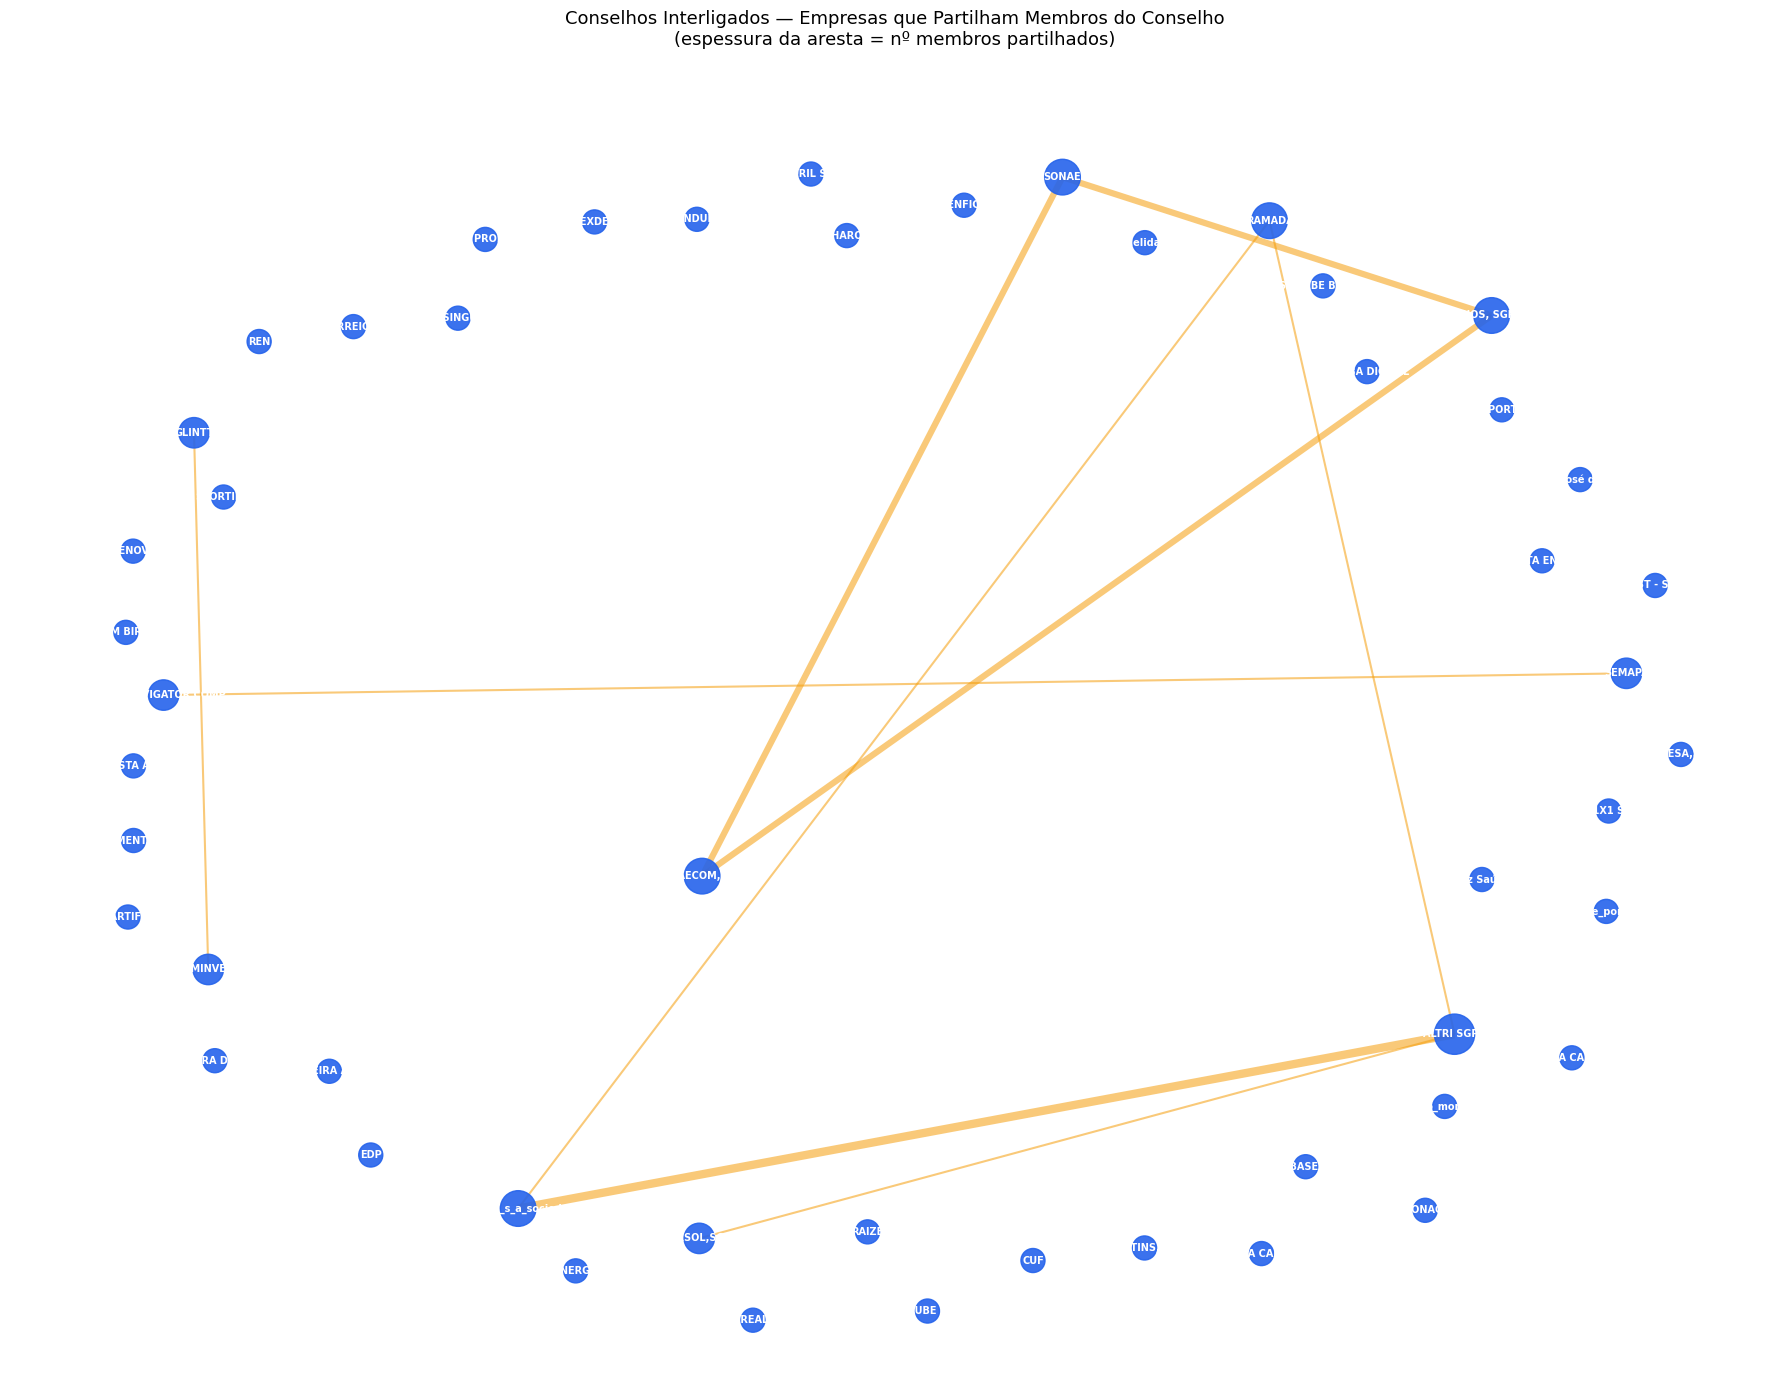

Imagem guardada: rede_interlock.png


In [8]:
# Build company-company graph: edge weight = number of shared board members
from collections import defaultdict

# Map person -> list of companies
person_companies = defaultdict(list)
for _, row in board_edges.iterrows():
    person_companies[row["source"]].append(row["target"])

# Count shared members between pairs of companies
shared = defaultdict(int)
for person, companies in person_companies.items():
    for i in range(len(companies)):
        for j in range(i + 1, len(companies)):
            pair = tuple(sorted([companies[i], companies[j]]))
            shared[pair] += 1

G_interlock = nx.Graph()
for cid in company_ids:
    label = dataset.loc[dataset["id"] == cid, "label"].values
    G_interlock.add_node(cid, label=label[0] if len(label) else cid)

for (c1, c2), count in shared.items():
    G_interlock.add_edge(c1, c2, weight=count)

# Degree (number of companies connected to)
degrees = dict(G_interlock.degree())
node_sizes_il = [300 + degrees.get(n, 0) * 180 for n in G_interlock.nodes]
edge_widths    = [G_interlock[u][v]["weight"] * 1.5 for u, v in G_interlock.edges]
labels_il      = {n: G_interlock.nodes[n].get("label", n) for n in G_interlock.nodes}

pos_il = nx.spring_layout(G_interlock, seed=7, k=2.5, weight="weight")

fig, ax = plt.subplots(figsize=(18, 14))
nx.draw_networkx_edges(G_interlock, pos_il, ax=ax,
                       width=edge_widths, alpha=0.55, edge_color="#F59E0B")
nx.draw_networkx_nodes(G_interlock, pos_il, ax=ax,
                       node_color="#2563EB", node_size=node_sizes_il, alpha=0.9)
nx.draw_networkx_labels(G_interlock, pos_il, labels=labels_il, ax=ax,
                        font_size=7, font_weight="bold", font_color="white")

shared_pairs = [(c1, c2, w) for (c1, c2), w in shared.items()]
shared_pairs.sort(key=lambda x: -x[2])
print("Pares com mais membros partilhados:")
for c1, c2, w in shared_pairs[:10]:
    l1 = dataset.loc[dataset["id"]==c1,"label"].values[0] if len(dataset.loc[dataset["id"]==c1,"label"].values) else c1
    l2 = dataset.loc[dataset["id"]==c2,"label"].values[0] if len(dataset.loc[dataset["id"]==c2,"label"].values) else c2
    print(f"  {l1}  <->  {l2}  : {w} membro(s) partilhado(s)")

ax.set_title("Conselhos Interligados — Empresas que Partilham Membros do Conselho\n(espessura da aresta = nº membros partilhados)", fontsize=13, pad=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("rede_interlock.png", dpi=150, bbox_inches="tight")
plt.show()
print("Imagem guardada: rede_interlock.png")

### 3. Rede de accionistas

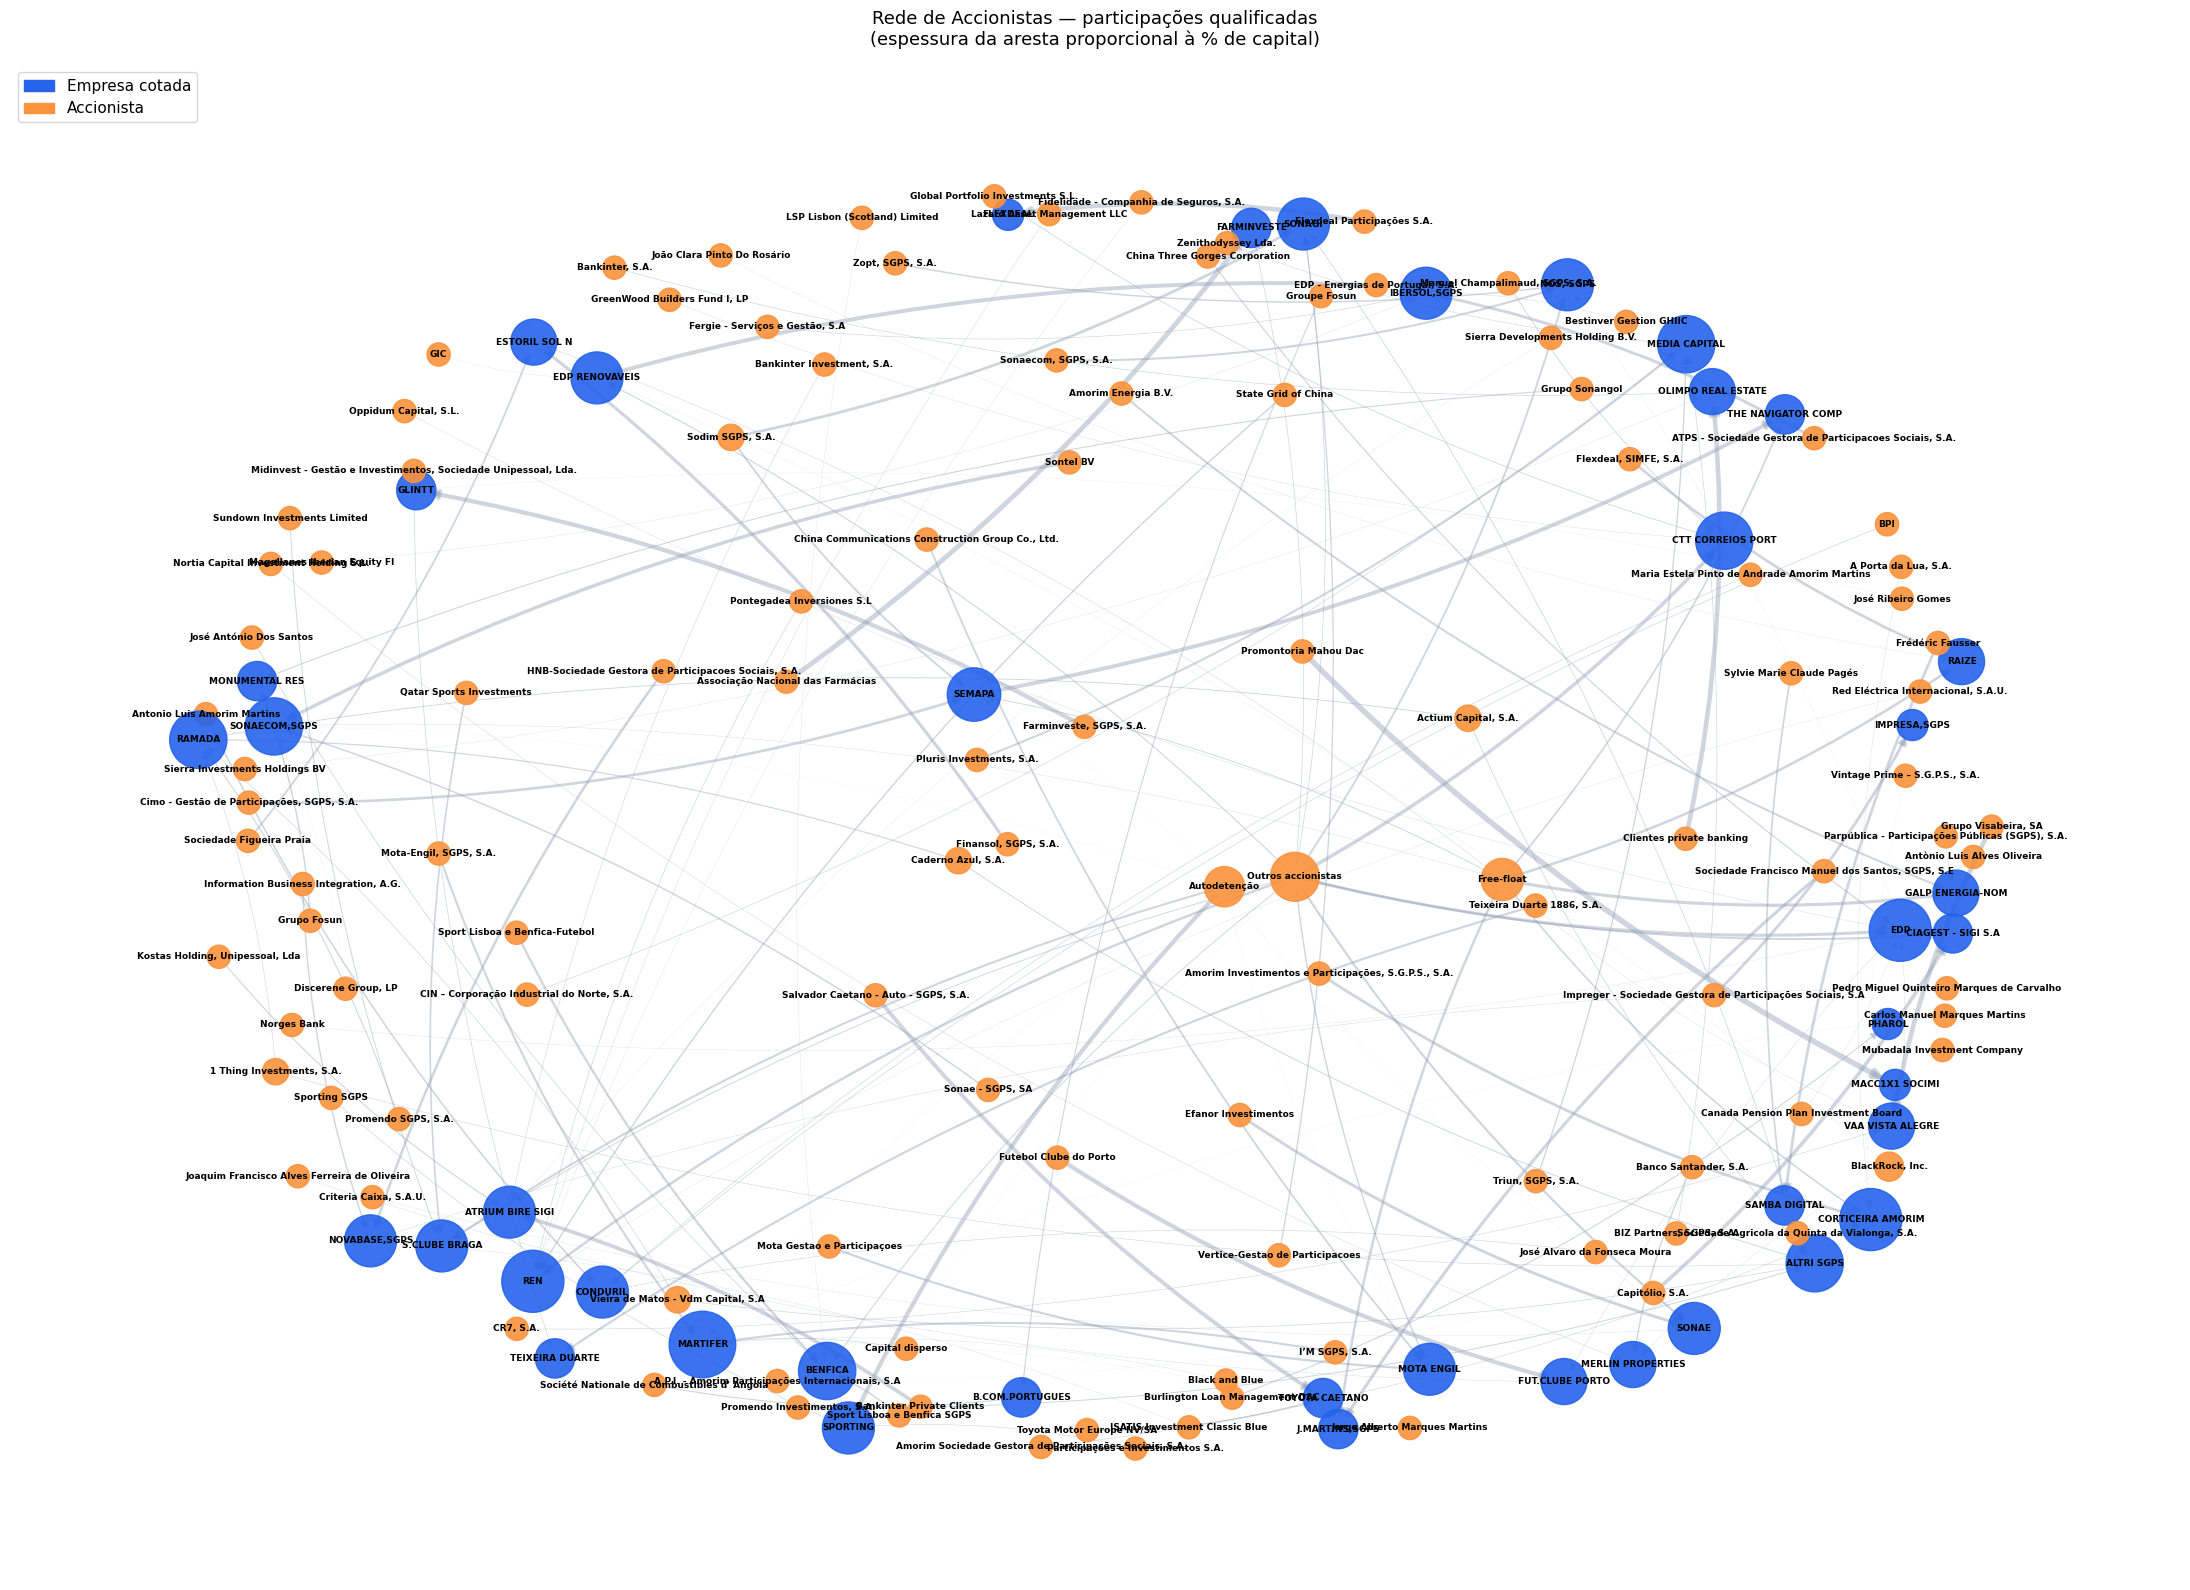

Imagem guardada: rede_accionistas.png


In [9]:
G_sh = nx.DiGraph()

all_sh_nodes = set(shareholder_edges["source"]) | set(shareholder_edges["target"])
for node in all_sh_nodes:
    row = dataset[dataset["id"] == node]
    ntype = row["type"].values[0] if len(row) else "shareholder"
    label = row["label"].values[0] if len(row) else node.replace("_", " ").title()
    G_sh.add_node(node, label=label, node_type=ntype)

for _, row in shareholder_edges.iterrows():
    G_sh.add_edge(row["source"], row["target"], weight=row["weight"])

node_colors_sh = []
for n in G_sh.nodes:
    t = G_sh.nodes[n].get("node_type", "shareholder")
    if t == "company":
        node_colors_sh.append("#2563EB")
    else:
        node_colors_sh.append("#FB923C")

in_deg  = dict(G_sh.in_degree())
out_deg = dict(G_sh.out_degree())
node_sizes_sh = [200 + in_deg.get(n, 0) * 300 + out_deg.get(n, 0) * 80
                 for n in G_sh.nodes]

labels_sh = {n: G_sh.nodes[n].get("label", n) for n in G_sh.nodes}
edge_weights_sh = [G_sh[u][v]["weight"] / 25 for u, v in G_sh.edges]

pos_sh = nx.spring_layout(G_sh, seed=21, k=2.2)

fig, ax = plt.subplots(figsize=(22, 16))
nx.draw_networkx_edges(G_sh, pos_sh, ax=ax,
                       width=edge_weights_sh, alpha=0.45,
                       edge_color="#94A3B8", arrows=True,
                       arrowstyle="-|>", arrowsize=12,
                       connectionstyle="arc3,rad=0.08")
nx.draw_networkx_nodes(G_sh, pos_sh, ax=ax,
                       node_color=node_colors_sh, node_size=node_sizes_sh, alpha=0.9)
nx.draw_networkx_labels(G_sh, pos_sh, labels=labels_sh, ax=ax,
                        font_size=6.5, font_weight="bold")

legend_sh = [
    mpatches.Patch(color="#2563EB", label="Empresa cotada"),
    mpatches.Patch(color="#FB923C", label="Accionista"),
]
ax.legend(handles=legend_sh, loc="upper left", fontsize=11)
ax.set_title("Rede de Accionistas — participações qualificadas\n(espessura da aresta proporcional à % de capital)", fontsize=13, pad=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("rede_accionistas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Imagem guardada: rede_accionistas.png")

### 4. Rede completa — accionistas + membros do conselho

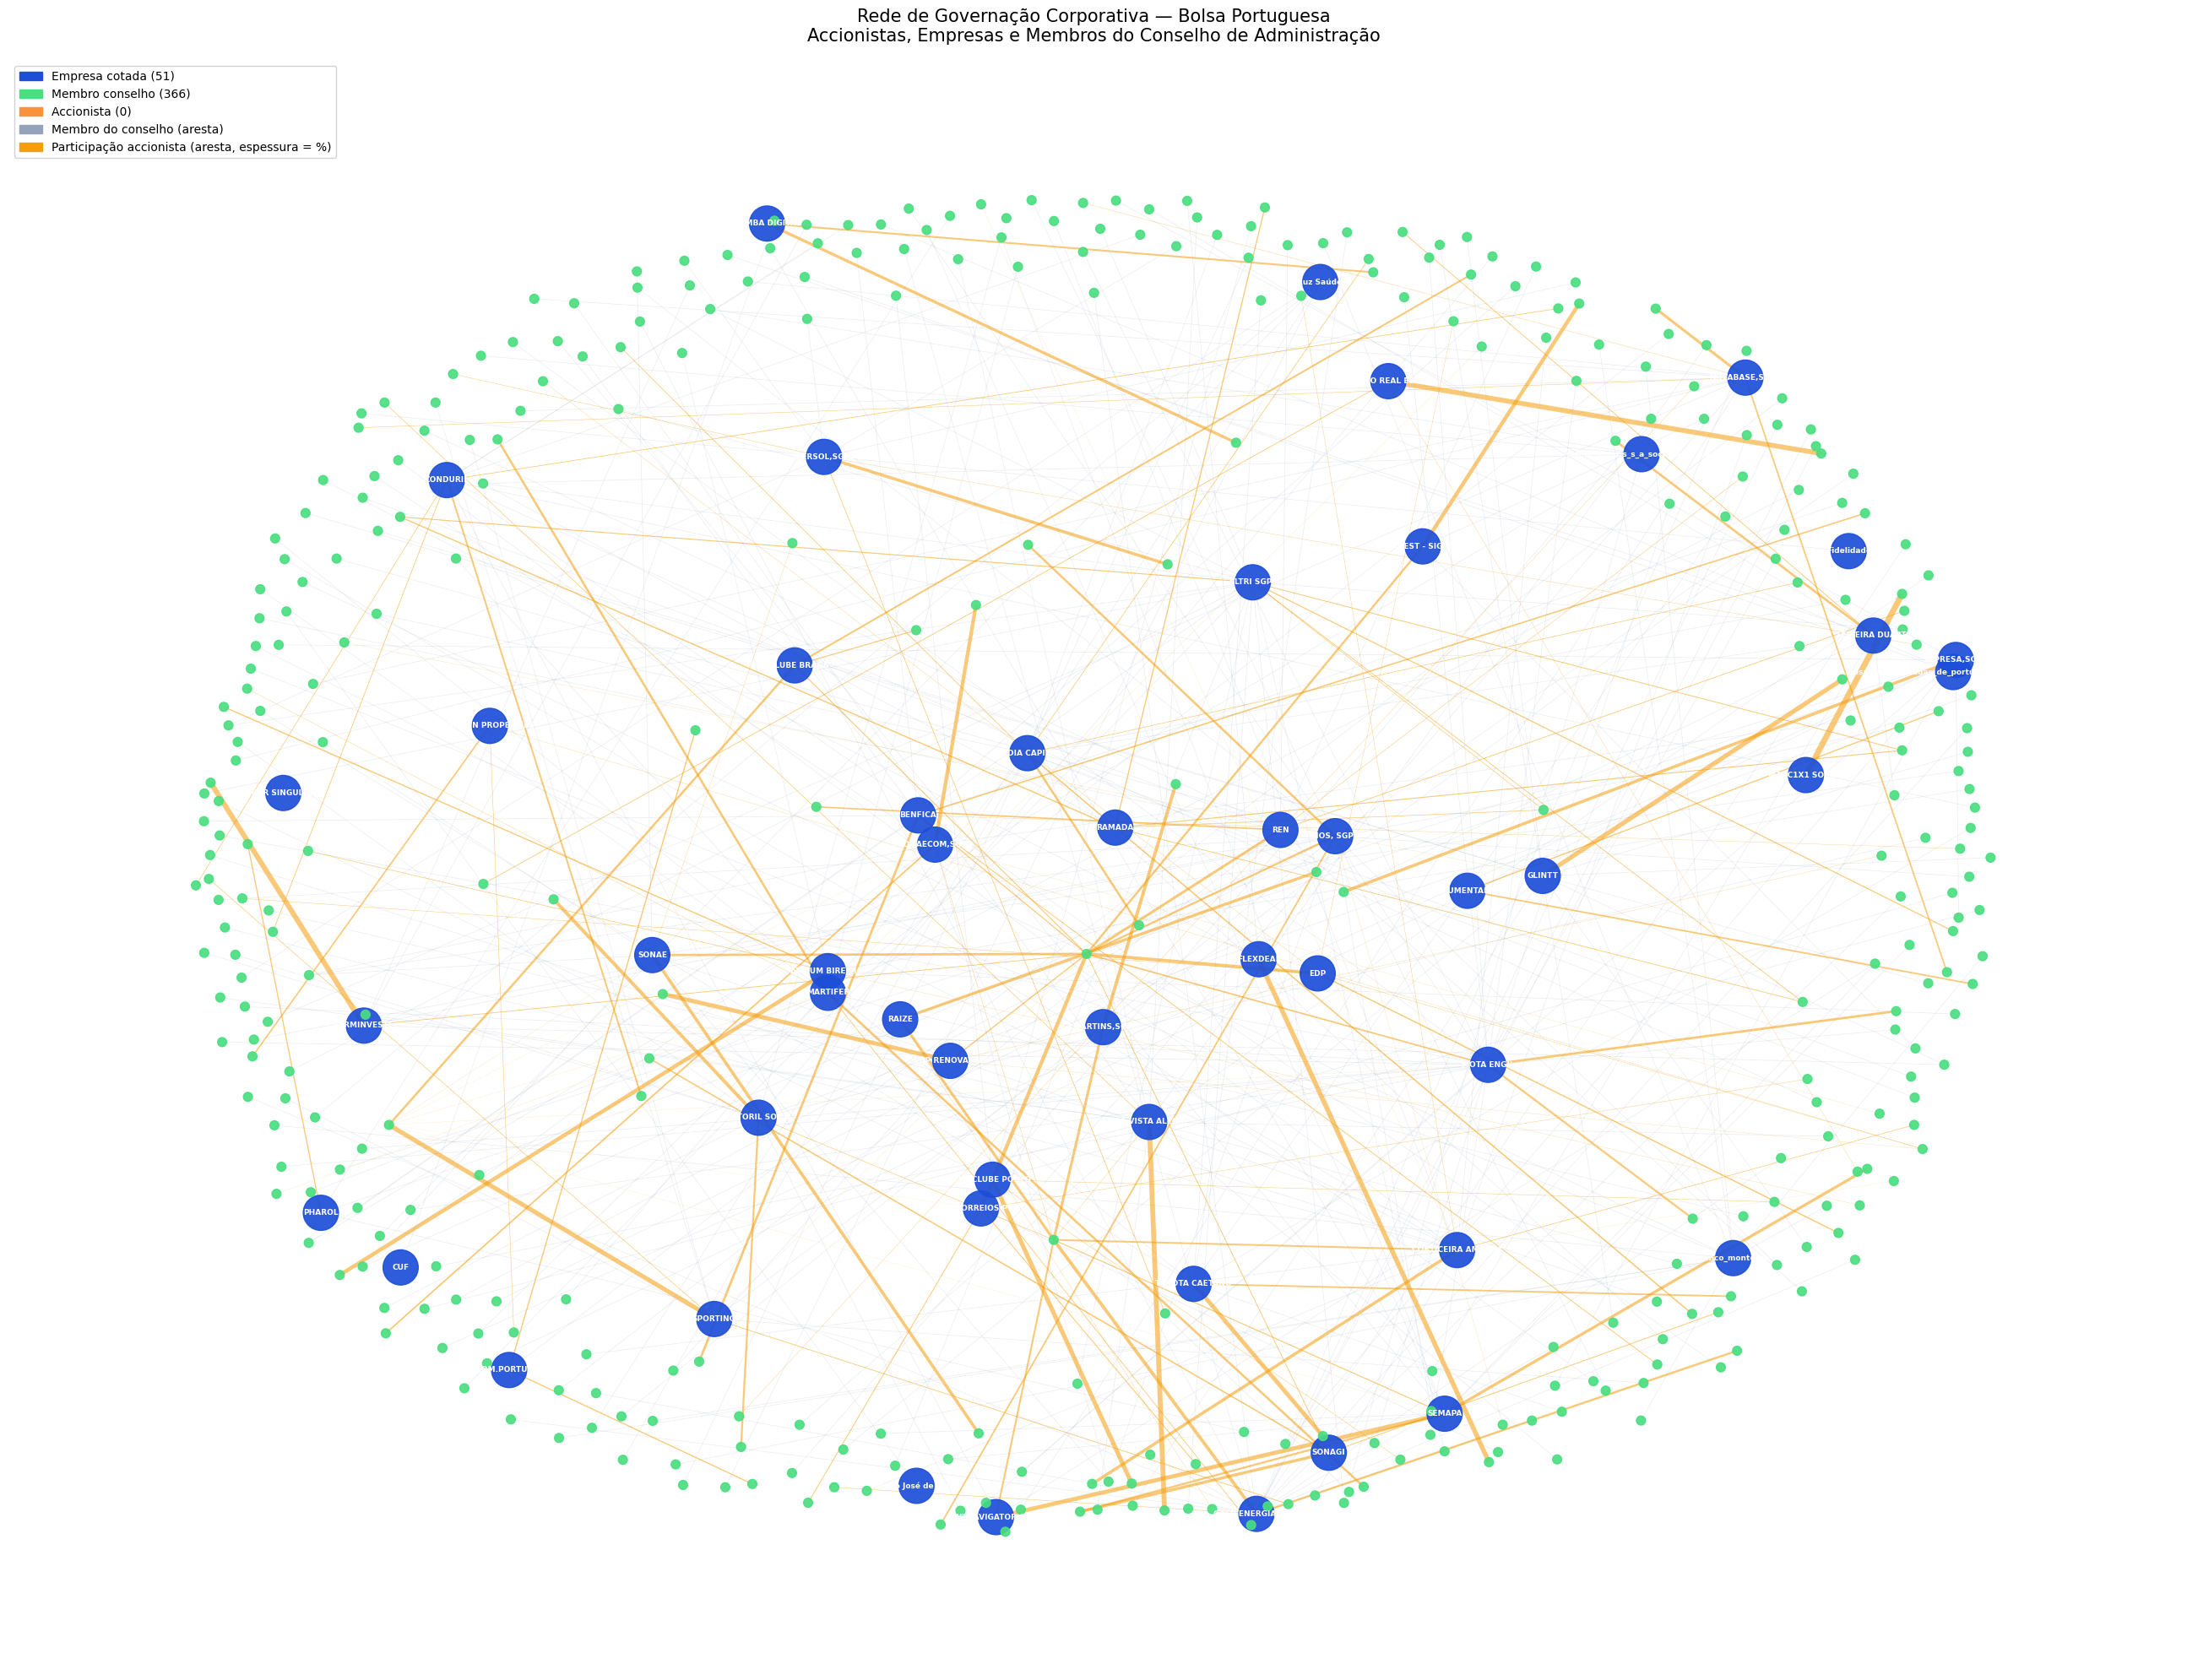

Imagem guardada: rede_completa.png


In [10]:
G_full = nx.Graph()

# --- Nodes ---
for _, row in dataset.iterrows():
    G_full.add_node(row["id"], label=row["label"], node_type=row["type"])

# Shareholder nodes not yet in dataset
for node in set(shareholder_edges["source"]) | set(shareholder_edges["target"]):
    if node not in G_full:
        label = node.replace("_", " ").title()
        G_full.add_node(node, label=label, node_type="shareholder")

# --- Edges ---
for _, row in board_edges.iterrows():
    G_full.add_edge(row["source"], row["target"], edge_type="board", weight=0.5)

for _, row in shareholder_edges.iterrows():
    G_full.add_edge(row["source"], row["target"], edge_type="shareholder", weight=row["weight"])

# --- Visual attributes per node ---
COLOR_MAP = {
    "company":     "#1D4ED8",   # blue  — empresa cotada
    "person":      "#4ADE80",   # green — membro conselho
    "shareholder": "#FB923C",   # orange — accionista
}
SIZE_MAP = {
    "company":     900,
    "person":      60,
    "shareholder": 220,
}

node_list   = list(G_full.nodes)
node_colors = [COLOR_MAP.get(G_full.nodes[n].get("node_type"), "#CBD5E1") for n in node_list]
node_sizes  = [SIZE_MAP.get(G_full.nodes[n].get("node_type"), 100)        for n in node_list]

# --- Visual attributes per edge ---
board_edge_list  = [(u, v) for u, v, d in G_full.edges(data=True) if d.get("edge_type") == "board"]
sh_edge_list     = [(u, v) for u, v, d in G_full.edges(data=True) if d.get("edge_type") == "shareholder"]
sh_edge_widths   = [G_full[u][v]["weight"] / 20 for u, v in sh_edge_list]

# Label only companies
labels_full = {n: G_full.nodes[n].get("label", n)
               for n in G_full.nodes
               if G_full.nodes[n].get("node_type") == "company"}

pos_full = nx.spring_layout(G_full, seed=42, k=1.6)

fig, ax = plt.subplots(figsize=(26, 20))

# Board edges — thin grey
nx.draw_networkx_edges(G_full, pos_full, edgelist=board_edge_list, ax=ax,
                       width=0.5, alpha=0.20, edge_color="#94A3B8")
# Shareholder edges — thicker amber, width ~ stake size
nx.draw_networkx_edges(G_full, pos_full, edgelist=sh_edge_list, ax=ax,
                       width=sh_edge_widths, alpha=0.55, edge_color="#F59E0B")

nx.draw_networkx_nodes(G_full, pos_full, nodelist=node_list, ax=ax,
                       node_color=node_colors, node_size=node_sizes, alpha=0.92)
nx.draw_networkx_labels(G_full, pos_full, labels=labels_full, ax=ax,
                        font_size=6.5, font_weight="bold", font_color="white")

legend_full = [
    mpatches.Patch(color="#1D4ED8", label=f"Empresa cotada ({sum(1 for n in G_full.nodes if G_full.nodes[n].get('node_type')=='company')})"),
    mpatches.Patch(color="#4ADE80", label=f"Membro conselho ({sum(1 for n in G_full.nodes if G_full.nodes[n].get('node_type')=='person')})"),
    mpatches.Patch(color="#FB923C", label=f"Accionista ({sum(1 for n in G_full.nodes if G_full.nodes[n].get('node_type')=='shareholder')})"),
    mpatches.Patch(color="#94A3B8", label="Membro do conselho (aresta)"),
    mpatches.Patch(color="#F59E0B", label="Participação accionista (aresta, espessura = %)"),
]
ax.legend(handles=legend_full, loc="upper left", fontsize=10, framealpha=0.85)
ax.set_title(
    "Rede de Governação Corporativa — Bolsa Portuguesa\n"
    "Accionistas, Empresas e Membros do Conselho de Administração",
    fontsize=15, pad=16
)
ax.axis("off")
plt.tight_layout()
plt.savefig("rede_completa.png", dpi=160, bbox_inches="tight")
plt.show()
print("Imagem guardada: rede_completa.png")

### shareholders e acionistas connectados

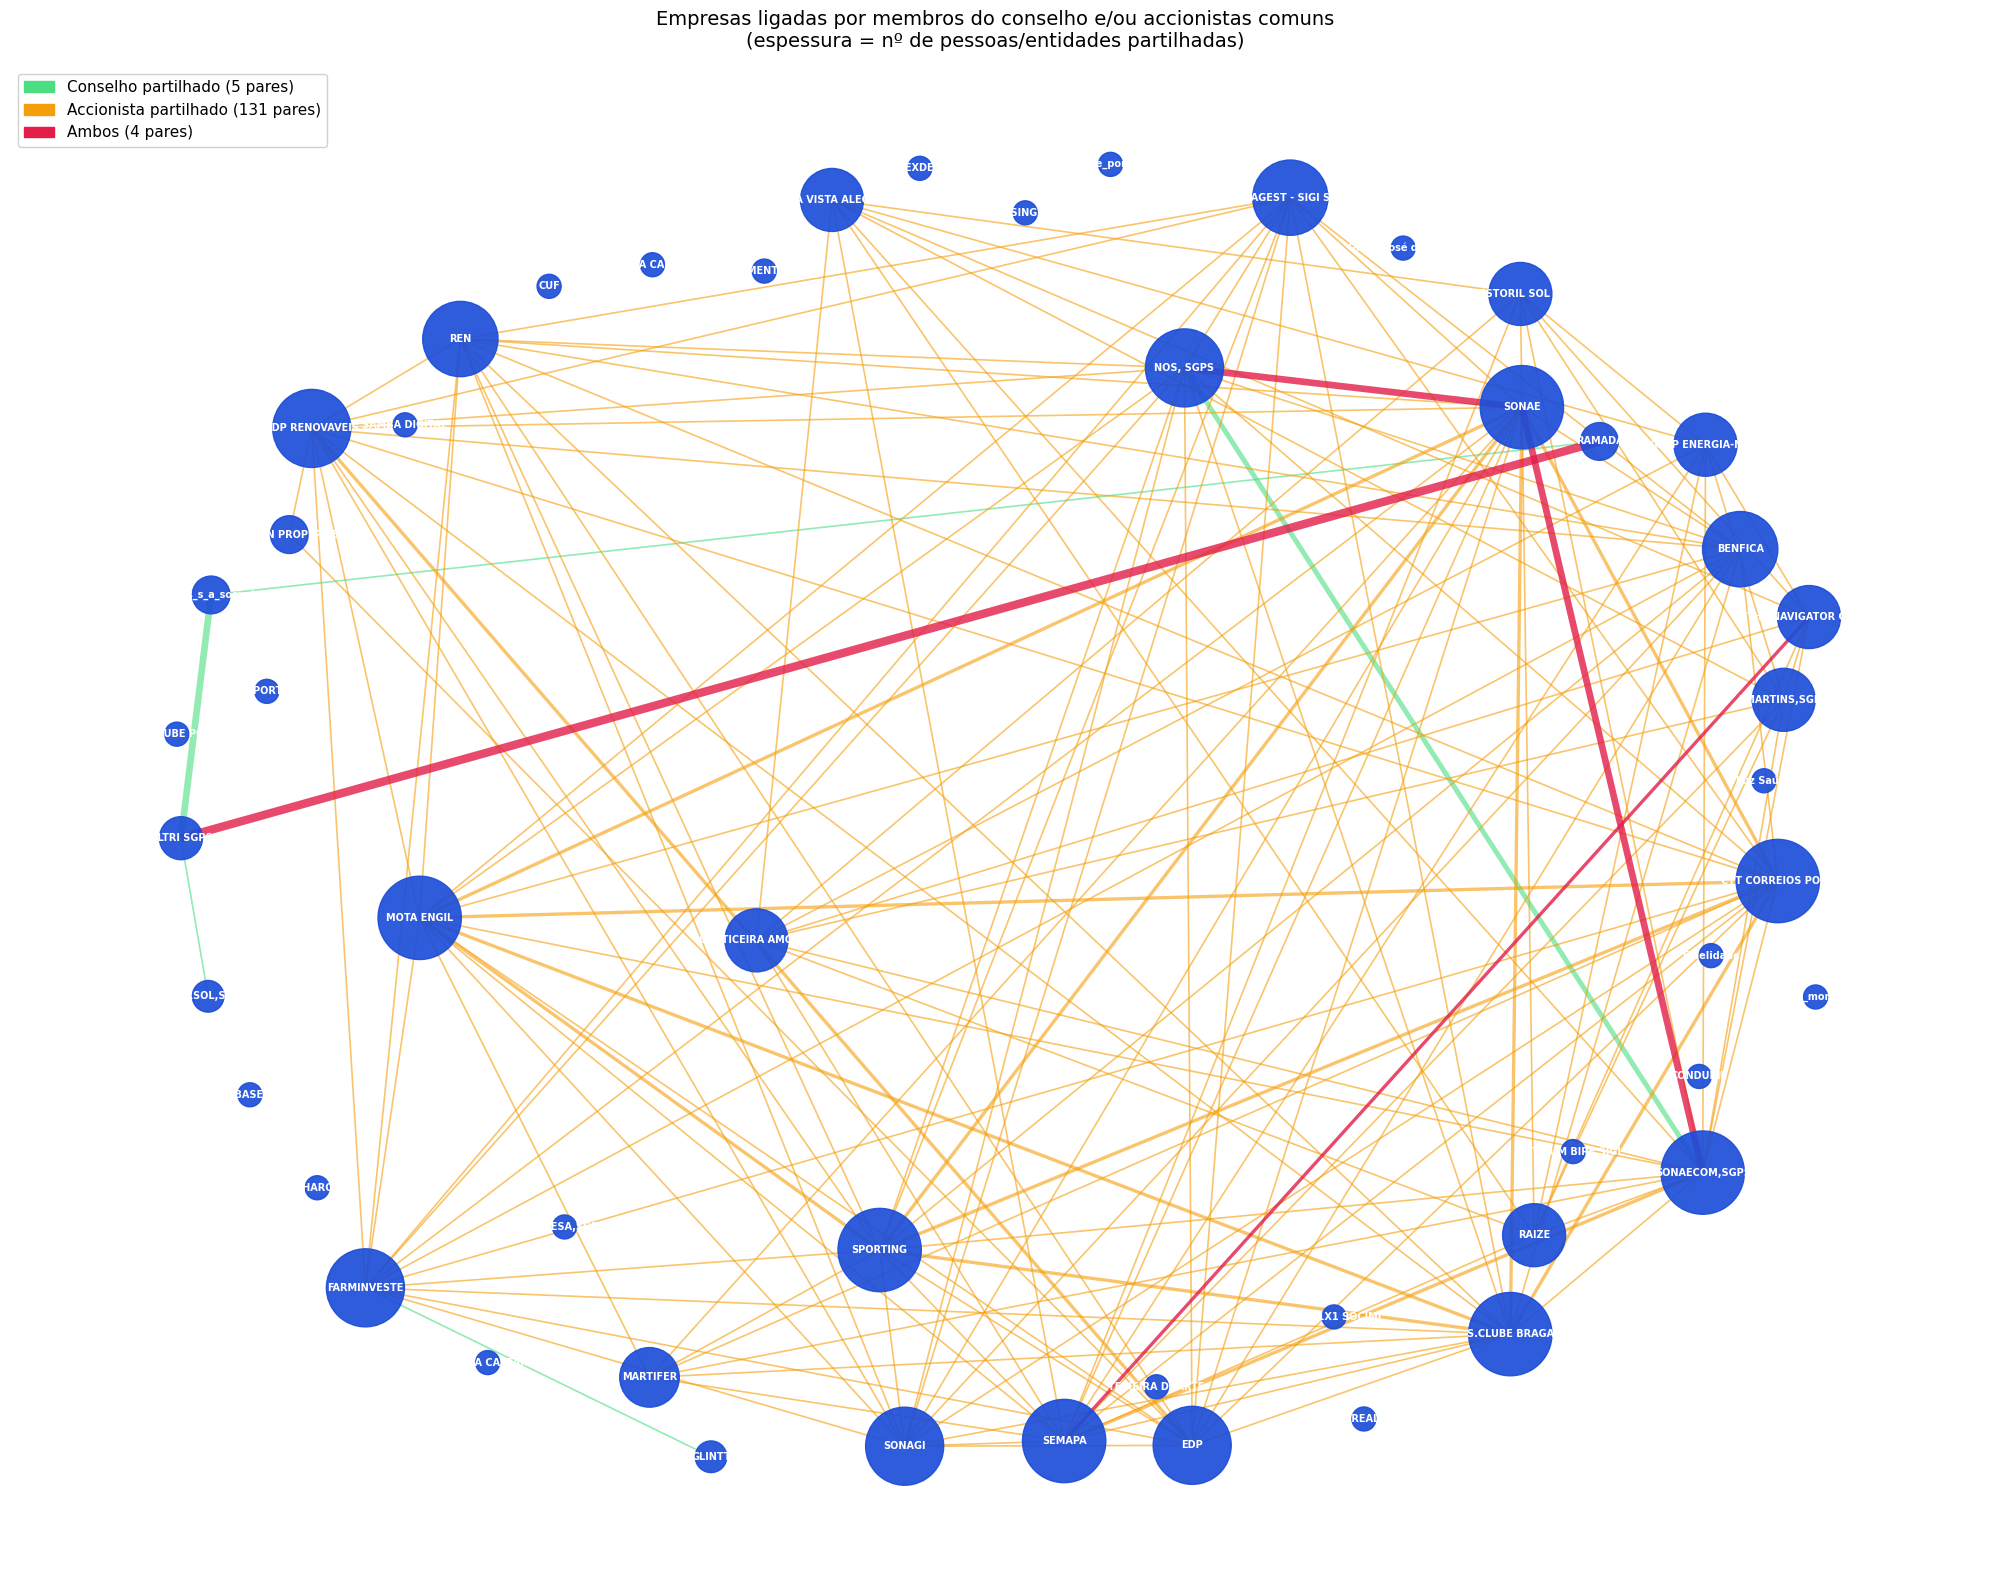


Total de pares de empresas ligados: 140
  Por conselho partilhado:  5
  Por accionista partilhado: 131
  Por ambos:                4

Top ligações mais fortes:
                        Empresa A                         Empresa B  Tipo  Membros conselho  Accionistas
                       ALTRI SGPS cofina_s_g_p_s_s_a_sociedade_2024 board                 4            0
                            SONAE                     SONAECOM,SGPS  both                 3            1
                            SONAE                         NOS, SGPS  both                 3            1
                        NOS, SGPS                     SONAECOM,SGPS board                 3            0
                       ALTRI SGPS                            RAMADA  both                 1            4
               THE NAVIGATOR COMP                            SEMAPA  both                 1            1
                           GLINTT                       FARMINVESTE board                 1            0

In [11]:
from collections import defaultdict
import itertools

# --- Shared board members ---
# person -> companies where they sit on the board
person_to_cos = defaultdict(set)
for _, row in board_edges.iterrows():
    person_to_cos[row["source"]].add(row["target"])

shared_board = defaultdict(set)   # (co_a, co_b) -> set of shared persons
for person, cos in person_to_cos.items():
    for a, b in itertools.combinations(sorted(cos), 2):
        shared_board[(a, b)].add(person)

# --- Shared shareholders ---
# shareholder -> companies they own a stake in
sh_to_cos = defaultdict(set)
for _, row in shareholder_edges.iterrows():
    sh_to_cos[row["source"]].add(row["target"])

shared_sh = defaultdict(set)      # (co_a, co_b) -> set of shared shareholders
for sh, cos in sh_to_cos.items():
    for a, b in itertools.combinations(sorted(cos), 2):
        shared_sh[(a, b)].add(sh)

# --- Build company-company graph ---
G_co = nx.Graph()

for cid in company_ids:
    lbl = dataset.loc[dataset["id"] == cid, "label"].values
    G_co.add_node(cid, label=lbl[0] if len(lbl) else cid)

all_pairs = set(shared_board) | set(shared_sh)
for pair in all_pairs:
    a, b = pair
    if a not in G_co or b not in G_co:
        continue
    has_board = pair in shared_board
    has_sh    = pair in shared_sh
    n_board   = len(shared_board.get(pair, []))
    n_sh      = len(shared_sh.get(pair, []))
    edge_type = "both" if (has_board and has_sh) else ("board" if has_board else "sh")
    G_co.add_edge(a, b, edge_type=edge_type, n_board=n_board, n_sh=n_sh)

# --- Split edge lists by type ---
edges_board = [(u,v) for u,v,d in G_co.edges(data=True) if d["edge_type"] == "board"]
edges_sh    = [(u,v) for u,v,d in G_co.edges(data=True) if d["edge_type"] == "sh"]
edges_both  = [(u,v) for u,v,d in G_co.edges(data=True) if d["edge_type"] == "both"]

w_board = [G_co[u][v]["n_board"] * 1.2 for u,v in edges_board]
w_sh    = [G_co[u][v]["n_sh"]    * 1.2 for u,v in edges_sh]
w_both  = [(G_co[u][v]["n_board"] + G_co[u][v]["n_sh"]) * 1.2 for u,v in edges_both]

deg = dict(G_co.degree())
node_sizes_co = [300 + deg.get(n, 0) * 220 for n in G_co.nodes]
labels_co = {n: G_co.nodes[n].get("label", n) for n in G_co.nodes}

pos_co = nx.spring_layout(G_co, seed=11, k=2.8, weight=None)

fig, ax = plt.subplots(figsize=(20, 16))

nx.draw_networkx_edges(G_co, pos_co, edgelist=edges_board, ax=ax,
                       width=w_board, alpha=0.6, edge_color="#4ADE80", label="Conselho partilhado")
nx.draw_networkx_edges(G_co, pos_co, edgelist=edges_sh, ax=ax,
                       width=w_sh,    alpha=0.6, edge_color="#F59E0B", label="Accionista partilhado")
nx.draw_networkx_edges(G_co, pos_co, edgelist=edges_both, ax=ax,
                       width=w_both,  alpha=0.8, edge_color="#E11D48", label="Conselho + Accionista")

nx.draw_networkx_nodes(G_co, pos_co, ax=ax,
                       node_color="#1D4ED8", node_size=node_sizes_co, alpha=0.92)
nx.draw_networkx_labels(G_co, pos_co, labels=labels_co, ax=ax,
                        font_size=7, font_weight="bold", font_color="white")

legend_co = [
    mpatches.Patch(color="#4ADE80", label=f"Conselho partilhado ({len(edges_board)} pares)"),
    mpatches.Patch(color="#F59E0B", label=f"Accionista partilhado ({len(edges_sh)} pares)"),
    mpatches.Patch(color="#E11D48", label=f"Ambos ({len(edges_both)} pares)"),
]
ax.legend(handles=legend_co, loc="upper left", fontsize=11, framealpha=0.9)
ax.set_title(
    "Empresas ligadas por membros do conselho e/ou accionistas comuns\n"
    "(espessura = nº de pessoas/entidades partilhadas)",
    fontsize=14, pad=14
)
ax.axis("off")
plt.tight_layout()
plt.savefig("rede_empresas_comuns.png", dpi=160, bbox_inches="tight")
plt.show()

# Summary table
print(f"\nTotal de pares de empresas ligados: {len(all_pairs)}")
print(f"  Por conselho partilhado:  {len(edges_board)}")
print(f"  Por accionista partilhado: {len(edges_sh)}")
print(f"  Por ambos:                {len(edges_both)}")
print("\nTop ligações mais fortes:")
rows_summary = []
for a, b, d in G_co.edges(data=True):
    la = G_co.nodes[a].get("label", a)
    lb = G_co.nodes[b].get("label", b)
    rows_summary.append({"Empresa A": la, "Empresa B": lb,
                         "Tipo": d["edge_type"],
                         "Membros conselho": d["n_board"],
                         "Accionistas": d["n_sh"]})
df_summary = pd.DataFrame(rows_summary).sort_values(
    ["Membros conselho", "Accionistas"], ascending=False
).reset_index(drop=True)
print(df_summary.head(15).to_string(index=False))
print("\nImagem guardada: rede_empresas_comuns.png")